# CIFAR10 Classification

In this part of the assignment we want to do an image classification task using PyTorch on CIFAR10 dataset.

## Import Libraries

Import needed libraries

In [ ]:
import torch
from torchvision import datasets
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import os
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchsummary import summary
from sklearn.manifold import TSNE
from datetime import datetime

## Device

Set device to work with (GPU or CPU)

In [ ]:
device =  ...
device

device(type='cuda')

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [ ]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:

cifar10_mean = np.array([0.49421428, 0.48513139, 0.45040909])
cifar10_std = np.array([0.24665252, 0.24289226, 0.26159238])

# Define the transform for the training set
transform_train = transforms.Compose([
  transforms.RandomCrop(32, padding=4),
  transforms.RandomHorizontalFlip(),
  transforms.ToTensor(),
  # Normalize the training set using cifar10_mean and cifar10_std
  ...
])

# Define the transform for the test set
transform_test = transforms.Compose([
  transforms.ToTensor(),
  # Normalize the test set using cifar10_mean and cifar10_std
  ...
])

# Define the unnormalize transform
unnormalize_transform = ...

In [ ]:
# Load the CIFAR10 dataset
cifar10_dataset = datasets.CIFAR10(root='dataset', train=True, download=True, transform=transform_train)

# Split the dataset into train and validation sets
train_dataset, val_dataset = random_split(cifar10_dataset, [45000, 5000])

# Define the test dataset
test_dataset = datasets.CIFAR10(root='dataset', train=False, download=True, transform=transform_test)

# Define the dataloaders for train, validation, and test sets
train_loader = ...
val_loader = ...
test_loader = ...


  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting dataset/cifar-10-python.tar.gz to dataset
Files already downloaded and verified


## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

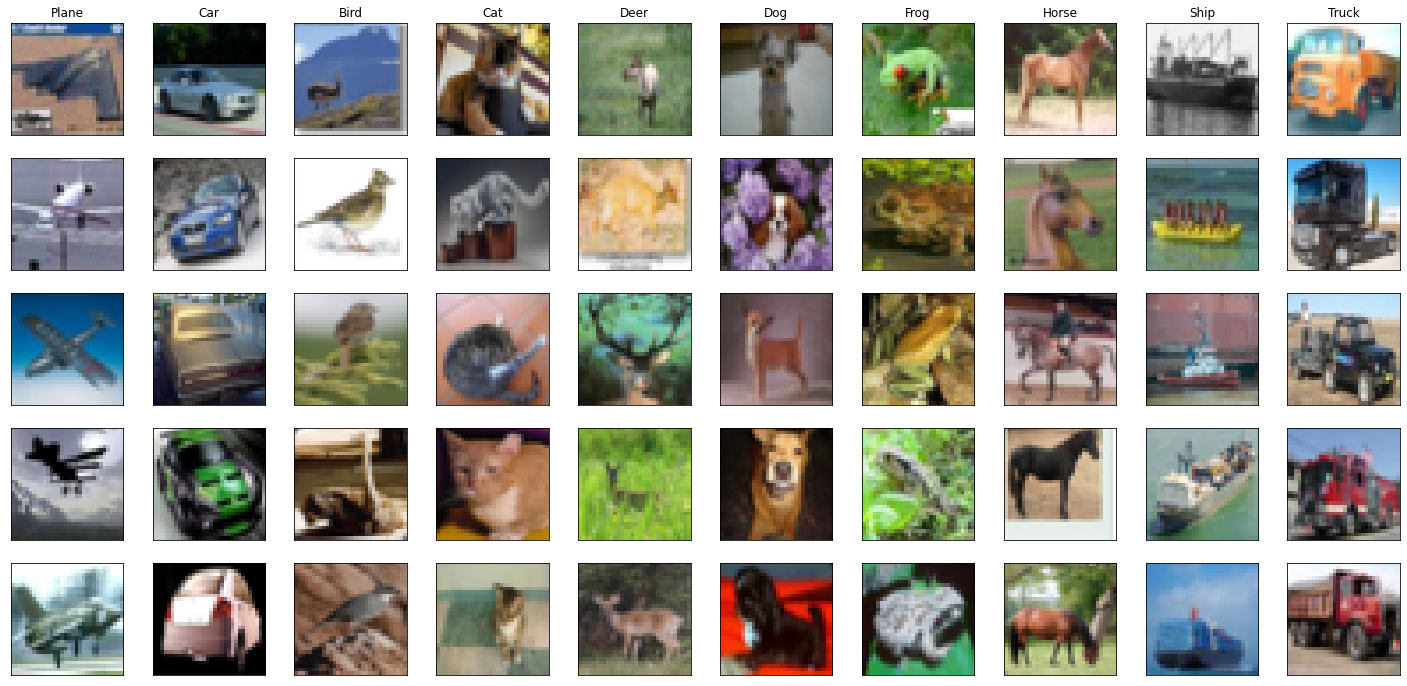

In [ ]:
num_images_to_display = 5
fig, axs = plt.subplots(num_images_to_display, len(classes), figsize=(25, 12))

# Display some images from each class in the training set

## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model)t have more than 10K parameters

**⚠️ Your model can not have more than 10K parameters ⚠️**

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

In [ ]:
# Sample network (with this model you'll get test accuracy above 85% but not 90%)
class SampleNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.feature_space = ...
    self.dropout = ...
    self.classifier = ...

  def forward(self, x):
    pass

In [ ]:
# ResNet18 implementation

class ResNetBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    assert stride == 1 or stride == 2

    super(ResNetBlock, self).__init__()

    self.block = ...

    if stride != 1 or in_channels != out_channels:
      self.shortcut = ...
    else:
      self.shortcut = ...

  def forward(self, x):
    # ! Pay more attention to the shortcut connection
    pass


class ResNet18(nn.Module):
  def __init__(self, img_channels=3, num_classes=10):
    super(ResNet18, self).__init__()

    self.feature_space = ...

    self.classifier = ...
  
  def forward(self, x):
    pass

## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [ ]:
model = SimpleNet().to(device)
# Print the model summary

# Print model parameters
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)
Suggestions:
- **Criterion**: `Cross Entropy Loss`
- **Optimizer**: `Adam` or `SGD` 
- **Learning Rate**: 0.001 or 0.01
- **Scheduler**: `StepLR`

In [ ]:
criterion = ...
optimizer = ...
scheduler = ...

### Train loop

Write a function to train your model 

Tasks:
- [ ] Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- [ ] save train/validation loss and accuracy (of each epoch) in an array for later usage

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=35, device='cuda'):
  """
  Train a PyTorch model and evaluate it on validation data
  
  Parameters:
  -----------
  model : The neural network model to train
  train_loader : DataLoader for the training dataset
  val_loader : DataLoader for the validation dataset
  criterion : Loss function
  optimizer : Optimizer for model parameters
  scheduler : Learning rate scheduler
  num_epochs : Number of epochs to train
  device : Device to use for training ('cuda' or 'cpu')
  
  Returns:
  --------
    model : The trained model
  dict
    Dictionary containing training history:
    - 'train_loss': list of training losses for each epoch
    - 'val_loss': list of validation losses for each epoch
    - 'train_acc': list of training accuracies for each epoch
    - 'val_acc': list of validation accuracies for each epoch
  """
  train_loss_arr, val_loss_arr = [], []
  train_acc_arr, val_acc_arr = [], []
  
  for epoch in range(num_epochs):
    train_loss, val_loss = .0, .0
    train_acc, val_acc = .0, .0

    # Training phase
    model.train()
    for images, labels in train_loader:
      ...

    # Validation phase
    model.eval()
    for images, labels in val_loader:
      ...

    # Calculate average loss and accuracy

    # Save metrics for plotting

    # Print progress
    if epoch % 5 == 0:
      print(f"[Epoch {epoch}]\t"
            f"[{datetime.now().strftime('%H:%M:%S')}]\t"
            f"Train Loss: {train_loss:.4f}\t"
            f"Train Accuracy: {train_acc:.2f}\t"
            f"Validation Loss: {val_loss:.4f}\t\t"
            f"Validation Accuracy: {val_acc:.2f}")
  
  return model, {
    'train_loss': train_loss_arr,
    'val_loss': val_loss_arr,
    'train_acc': train_acc_arr,
    'val_acc': val_acc_arr

### Train your model

- [ ] Train your model for 30~50 epochs
- [ ] Save your model after training with the name `simple_cnn.pth`


In [ ]:
num_epochs=...
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, device=device)


### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(21, 7))

axs[0].set_title("Loss plot")
axs[0].plot(train_loss_arr)
axs[0].plot(val_loss_arr)
axs[0].legend(["Train Loss", "Validation Loss"]);

axs[1].set_title("Accuracy plot")
axs[1].plot(train_acc_arr)
axs[1].plot(val_acc_arr)
axs[1].legend(["Train Accuracy", "Validation Accuracy"]);

## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy under 80% on the test set

In [ ]:
model = ResNet18().to(device)

# Print the model summary

# Print model parameters
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

# Train the ResNet18 model
num_epochs=...
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, device=device)

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(21, 7))

axs[0].set_title("Loss plot")
axs[0].plot(train_loss_arr)
axs[0].plot(val_loss_arr)
axs[0].legend(["Train Loss", "Validation Loss"]);

axs[1].set_title("Accuracy plot")
axs[1].plot(train_acc_arr)
axs[1].plot(val_acc_arr)
axs[1].legend(["Train Accuracy", "Validation Accuracy"]);

Now that you have trained your model, it's time to train the ResNet model. 

0.9365


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model

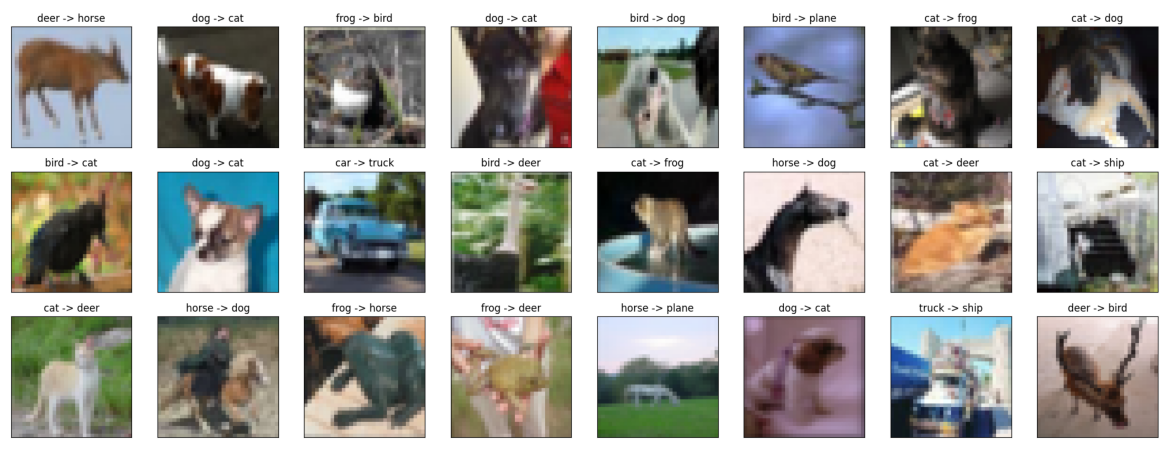

In [ ]:
num_rows, num_cols = 3, 8
num_wrong_pred_to_show = num_rows * num_cols

wrong_labeled_imgs = []
model.eval()
# Get wrong predictions

# Display wrong predictions